# Diamonds Price Prediction - Linear Regression Model

## 1 .Imports

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Data

In [2]:
df = pd.read_excel(
    "diamonds.xlsx",
    sheet_name="diamonds"
) 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carat         53794 non-null  float64
 1   Cut           53794 non-null  object 
 2   Cut Rank      53794 non-null  int64  
 3   Color         53794 non-null  object 
 4   Color Rank    53794 non-null  int64  
 5   Clarity       53794 non-null  object 
 6   Clarity Rank  53794 non-null  int64  
 7   Depth         53794 non-null  float64
 8   Table         53794 non-null  float64
 9   Price         53794 non-null  int64  
 10  Length (x)    53794 non-null  float64
 11  Width (y)     53794 non-null  float64
 12  Height (z)    53794 non-null  float64
 13  Volume_mm3    53794 non-null  float64
dtypes: float64(7), int64(4), object(3)
memory usage: 5.7+ MB


In [4]:
x = df[["Carat"]]
y = df["Price"]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size= 0.2 , 
    random_state=42
)

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [7]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [8]:
y_hat = pipeline.predict(x_test)

print("Prediction")
print(y_hat[0:20])

print("\nActual")
print(y_test.values[0:20])

Prediction
[ 3253.4555831   4728.33757726  2166.7004295   1700.94822082
  6979.47325255   381.31696289   303.69159478  3253.4555831
  1079.94527591  5659.84199462  3331.08095121  5582.21662651
  6358.47030764  1623.32285271  5582.21662651 13422.37880599
  4107.33463235  9773.98650465  5271.71515405   381.31696289]

Actual
[ 1435  3584  1851  1590  5690   596   492  2063   970  4796  2476  8579
  5000  1197 10888 14766  3535  7416  4900   974]


In [9]:
mse = mean_squared_error(y_test,y_hat)

r2 = r2_score(y_test, y_hat)
print(f"MSE = {mse}")
print(f"\nr2_score = {r2}")

MSE = 2317072.379640949

r2_score = 0.8479817802699159


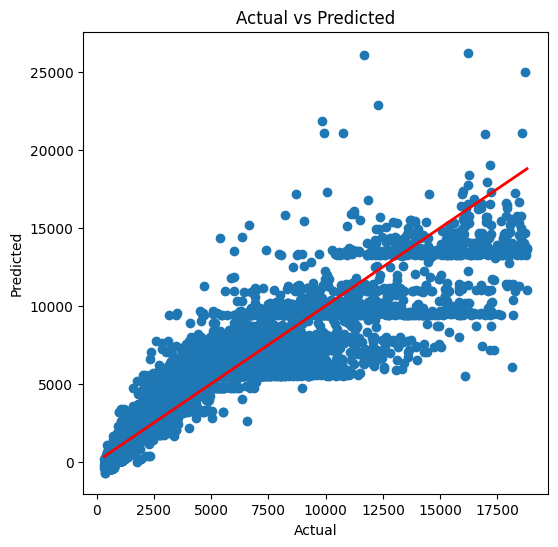

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_hat)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()